In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeansModel

# 1. Iniciamos Spark
spark = SparkSession.builder.appName("S12_Supervisados").getOrCreate()

# 2. CARGAR LOS DATOS (Esto lee el parquet donde guardaste los clusters)
# Asegúrate que esta ruta contenga archivos tipo 'part-00000...'
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

print("✅ Datos recuperados:")
df_clusters.show(5)

# 3. CARGAR EL MODELO (Aquí cargamos el "cerebro" para clasificar nuevos datos)
# Nota: La ruta debe ser la misma que usaste en .save()
ruta_modelo = "/home/jovyan/work/semanas/Semana 10/modelos/kmeans_inmobiliario_v1"
model_recuperado = KMeansModel.load(ruta_modelo)

print("✅ Modelo cargado y listo para nuevas predicciones.")

✅ Datos recuperados:
+--------------------+-----+-----------+--------------------+---------------+-------------------+--------+--------------------+----------+---+-------+-------+-------+----------------+-------+--------------------+---------+--------------------+--------------------+----------+
|                 _id|banos|dormitorios|              enlace|estacionamiento|   fecha_extraccion|gimnasio|              imagen|lavanderia| m2|piscina| precio|quincho|     responsable|terraza|              titulo|ubicacion|            features|      scaledFeatures|prediction|
+--------------------+-----+-----------+--------------------+---------------+-------------------+--------+--------------------+----------+---+-------+-------+-------+----------------+-------+--------------------+---------+--------------------+--------------------+----------+
|https://casas.mit...|    1|          2|https://casas.mit...|              1|2026-05-01 21:12:48|       0|https://img.mitul...|         0| 44|      1| 

In [2]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Renombramos 'prediction' a 'label' para el modelo supervisado
# Spark ML requiere que la columna objetivo se llame siempre 'label'
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. Dividimos los datos en Entrenamiento (70%) y Prueba (30%)
# El seed=42 asegura que si ejecutas el código varias veces, 
# la división de los datos sea siempre la misma (reproducibilidad).
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Datos de entrenamiento: {train_data.count()}")
print(f"Datos de prueba: {test_data.count()}")

Datos de entrenamiento: 1818
Datos de prueba: 700


In [3]:
from pyspark.ml.classification import DecisionTreeClassifier

# =====================================================================
# PASO 6: ENTRENAR EL ÁRBOL DE DECISIÓN
# =====================================================================

# 1. Configurar el modelo supervisado
# Usamos 'scaledFeatures' (que es el vector normalizado que creamos en el Paso 3)
# labelCol es 'label', que es la columna 'prediction' del K-Means renombrada
dt = DecisionTreeClassifier(
    featuresCol="scaledFeatures", 
    labelCol="label", 
    maxDepth=5, 
    seed=42
)

# 2. Entrenar el modelo con los datos de entrenamiento
print("🌳 Entrenando el Árbol de Decisión...")
dt_model = dt.fit(train_data)

# 3. Hacer predicciones sobre los datos de prueba
predictions_supervisadas = dt_model.transform(test_data)

# 4. Mostrar las primeras predicciones junto a la etiqueta real del K-Means
print("✅ Predicciones vs. Etiquetas reales (Clúster):")
predictions_supervisadas.select("titulo", "label", "prediction", "probability").show(10, truncate=False)

🌳 Entrenando el Árbol de Decisión...
✅ Predicciones vs. Etiquetas reales (Clúster):
+--------------------------------------------------+-----+----------+-----------------------------+
|titulo                                            |label|prediction|probability                  |
+--------------------------------------------------+-----+----------+-----------------------------+
|Sin título                                        |5    |5.0       |[0.0,0.0,0.0,0.0,0.0,1.0,0.0]|
|Departamento Puerta mar ID: 167413r               |5    |5.0       |[0.0,0.0,0.0,0.0,0.0,1.0,0.0]|
|Departamento Puerta mar ID: 167367r               |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Arriendo depart

In [4]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================================
# PASO 7: EVALUACIÓN DEL MODELO (MATRIZ DE CONFUSIÓN Y ACCURACY)
# =====================================================================

# 1. Configurar el evaluador para medir el Accuracy ($Accuracy$)
# labelCol es la columna 'label' (que viene del K-Means)
# predictionCol es la columna 'prediction' (la que generó el Árbol)
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)

# 2. Calcular la precisión sobre los datos de prueba
accuracy = evaluator.evaluate(predictions_supervisadas)

# 3. Imprimir resultado
print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")

Precisión del Árbol de Decisión (Accuracy): 99.14%


In [5]:
# =====================================================================
# PASO 8: VISUALIZAR LA LÓGICA DEL ÁRBOL
# =====================================================================

print("=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

=== ESTRUCTURA LÓGICA DEL ÁRBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_fb50a0130173, depth=5, numNodes=33, numClasses=7, numFeatures=4
  If (feature 2 <= 2.6346778979210974)
   If (feature 1 <= 2.550791792478912)
    If (feature 0 <= 0.5473187470979918)
     If (feature 3 <= 1.1602484234469996)
      Predict: 5.0
     Else (feature 3 > 1.1602484234469996)
      If (feature 0 <= 0.011184331834206382)
       Predict: 5.0
      Else (feature 0 > 0.011184331834206382)
       Predict: 3.0
    Else (feature 0 > 0.5473187470979918)
     Predict: 2.0
   Else (feature 1 > 2.550791792478912)
    If (feature 0 <= 0.5473187470979918)
     If (feature 1 <= 3.5711085094704766)
      Predict: 4.0
     Else (feature 1 > 3.5711085094704766)
      Predict: 6.0
    Else (feature 0 > 0.5473187470979918)
     Predict: 2.0
  Else (feature 2 > 2.6346778979210974)
   If (feature 0 <= 0.5473187470979918)
    If (feature 3 <= 1.1602484234469996)
     If (feature 1 <= 13.774275679386125)

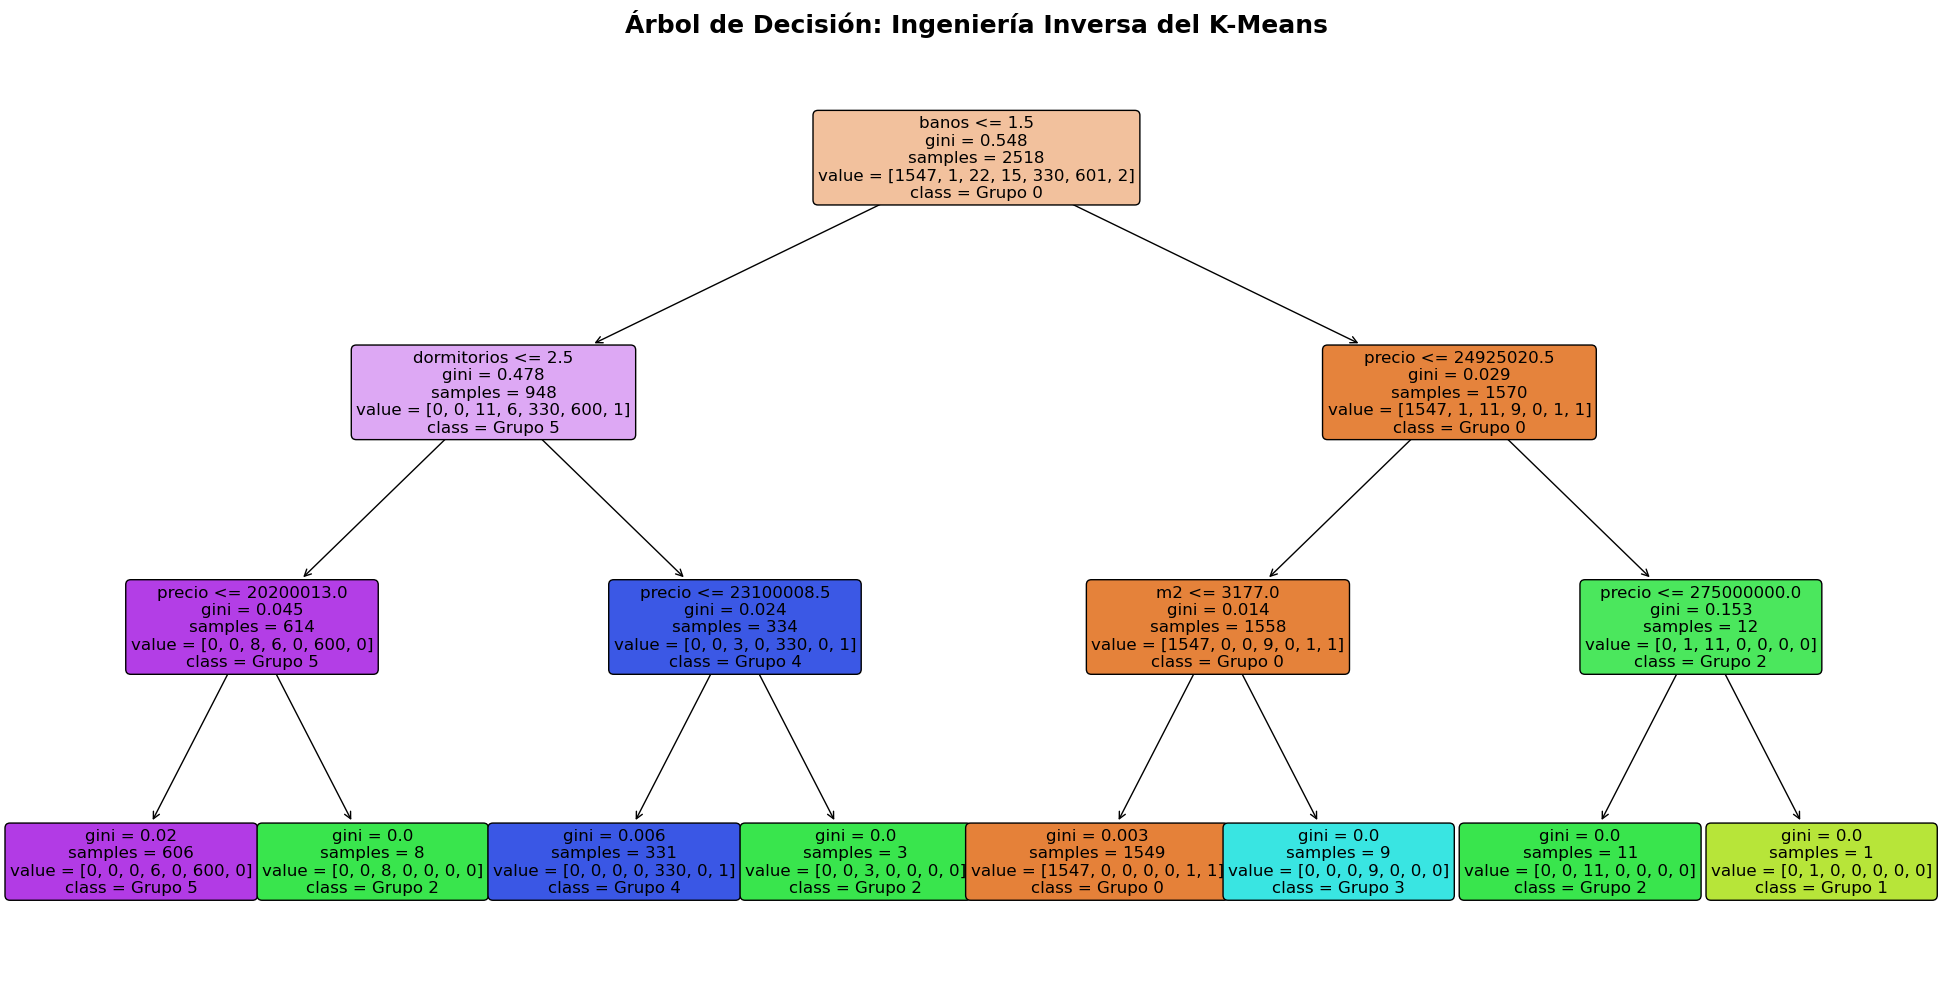

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# =====================================================================
# PASO 9: VISUALIZACIÓN GRÁFICA DEL ÁRBOL DE DECISIÓN
# =====================================================================

# 1. Convertimos una muestra de nuestro DataFrame de Spark a Pandas
# Seleccionamos las mismas variables numéricas que usamos en el VectorAssembler
df_pandas = df_supervisado.select("precio", "dormitorios", "banos", "m2", "label").toPandas()

# 2. Separamos las características (X) y la etiqueta (y)
X_muestra = df_pandas[["precio", "dormitorios", "banos", "m2"]]
y_muestra = df_pandas["label"]

# 3. Entrenamos el modelo de Scikit-Learn
# max_depth=3 para que el gráfico sea legible y no un árbol gigante
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# 4. Configuramos las etiquetas y nombres para el gráfico
nombres_features = ["precio", "dormitorios", "banos", "m2"]
# Convertimos los números de cluster a texto para que sea más didáctico
nombres_clases = [f"Grupo {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol de forma visual
plt.figure(figsize=(20, 10), dpi=100)
plot_tree(
    sk_dt,
    feature_names=nombres_features,
    class_names=nombres_clases,
    filled=True,      # Colores según la clase mayoritaria
    rounded=True,     # Bordes redondeados
    fontsize=12
)

plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# =====================================================================
# PASO 11.3.1: PREPARACIÓN PARA ALGORITMOS SUPERVISADOS
# =====================================================================

# 1. Renombramos 'prediction' (la etiqueta que generó el K-Means) a 'label'
# Esto es necesario porque los modelos supervisados de Spark siempre buscan una columna llamada 'label'
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# 2. Dividimos los datos: 70% para entrenamiento, 30% para prueba
# Usamos seed=42 para que la división sea siempre igual cada vez que ejecutes el código
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Registros de Entrenamiento: {train_data.count()}")
print(f"Registros de Prueba: {test_data.count()}")

Registros de Entrenamiento: 1818
Registros de Prueba: 700


In [9]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================================
# PASO 11.3.2: ENTRENAMIENTO DE LOS 3 MODELOS
# =====================================================================

# Creamos el evaluador común para medir el Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)

# ==========================================
# MODELO 1: Random Forest (Bosque Aleatorio)
# ==========================================
# Usamos 'scaledFeatures' por homogeneidad con los otros modelos
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)
print(f"Accuracy Random Forest: {accuracy_rf * 100:.2f}%")

# ==========================================
# MODELO 2: SVM (Máquina de Vectores de Soporte)
# ==========================================
# Usamos OneVsRest porque SVM nativo solo soporta clasificación binaria
svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)
print(f"Accuracy SVM: {accuracy_svm * 100:.2f}%")

# ==========================================
# MODELO 3: Regresión Logística Multinomial
# ==========================================
# Ideal para problemas multiclase y probabilidades
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)
print(f"Accuracy Regresión Logística: {accuracy_lr * 100:.2f}%")

Accuracy Random Forest: 98.86%
Accuracy SVM: 99.86%
Accuracy Regresión Logística: 100.00%


In [10]:
# =====================================================================
# PASO 11.3.3: TABLA COMPARATIVA DE RESULTADOS
# =====================================================================

print("==================================================")
print(" RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) ")
print("==================================================")
print(f"1. Random Forest Accuracy: {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy: {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy: {accuracy_lr * 100:.2f}%")
print("==================================================")

 RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) 
1. Random Forest Accuracy: 98.86%
2. SVM (OneVsRest) Accuracy: 99.86%
3. Regresión Logística Accuracy: 100.00%


In [11]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression

# =====================================================================
# 11.4.1: PREPARACIÓN DE LOS DATOS PARA REGRESIÓN (CON TÍTULO)
# =====================================================================

# 1. Renombramos 'precio' a 'label' y manejamos los títulos vacíos
# Si 'titulo' es nulo o vacío, ponemos "Sin título"
df_prep = df_clusters.withColumnRenamed("precio", "label") \
                     .withColumn("titulo", when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo")))

# 2. VectorAssembler (mantenemos 'titulo' para usarlo después)
assembler_regresion = VectorAssembler(
    inputCols=["dormitorios", "banos", "m2"],
    outputCol="features_regresion"
)
df_vector_reg = assembler_regresion.transform(df_prep)

# 3. Escalamos
scaler_reg = StandardScaler(
    inputCol="features_regresion", 
    outputCol="scaledFeatures_regresion"
)
scaler_model_reg = scaler_reg.fit(df_vector_reg)
df_para_regresion = scaler_model_reg.transform(df_vector_reg)

# 4. Limpieza: Borramos columnas que no sirven para el modelo matemático
# ¡CUIDADO! No borramos 'titulo' ni 'label'
columnas_a_borrar = ["prediction", "enlace", "imagen", "ubicacion", "fecha_extraccion", "responsable"]
df_para_regresion = df_para_regresion.drop(*columnas_a_borrar)

# 5. EL FILTRO MÁGICO
df_regresion_limpio = df_para_regresion.filter(
    (col("label") <= 2500000) &
    (col("label") >= 100000) &
    (col("m2").isNotNull()) &
    (col("m2") <= 400)
)

# 6. División
train_reg, test_reg = df_regresion_limpio.randomSplit([0.7, 0.3], seed=42)
print(f"Datos limpios - Entrenamiento: {train_reg.count()} | Prueba: {test_reg.count()}")

Datos limpios - Entrenamiento: 1609 | Prueba: 606


In [12]:
# =====================================================================
# 11.4.2 ENTRENAR EL MODELO DE REGRESIÓN LINEAL
# =====================================================================

lr_regresion = LinearRegression(
    featuresCol="scaledFeatures_regresion",
    labelCol="label",
    maxIter=10
)

print("📈 Entrenando el modelo de Regresión Lineal...")
lr_reg_model = lr_regresion.fit(train_reg)

# 3. Predicciones
predictions_regresion = lr_reg_model.transform(test_reg)

# 4. Mostrar comparativa con título
print("=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
predictions_regresion.select("titulo", "label", "prediction").show(10, truncate=False)

📈 Entrenando el modelo de Regresión Lineal...
=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
+--------------------------------------------------+------+------------------+
|titulo                                            |label |prediction        |
+--------------------------------------------------+------+------------------+
|Sin título                                        |550000|497878.9459492683 |
|Departamento Puerta mar ID: 167413r               |520000|487921.3071613659 |
|Departamento Puerta mar ID: 167367r               |360000|637828.9117012968 |
|Sin título                                        |348500|613978.2418583566 |
|Sin título                                        |490000|633403.2944622291 |
|Sin título                                        |650000|648892.9547989662 |
|Arriendo departamento nuevo en La Herradura       |500000|627255.0935755599 |
|Arriendo Departamento Nova Alto Hacienda, Coquimbo|570000|505133.55114570446|
|Sin título                      

In [13]:
from pyspark.ml.evaluation import RegressionEvaluator

# =====================================================================
# 11.4.3 EVALUAR EL MODELO DE REGRESIÓN (MÉTRICAS)
# =====================================================================

# 1. Configurar los evaluadores de regresión
# Usamos "label" porque así nombramos a la columna de precio real
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")

# 2. Calcular las métricas con los datos de prueba
r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

# 3. Imprimir el cuadro resumen
print("==================================================")
print(" 📊 EVALUACIÓN DE LA REGRESIÓN INMOBILIARIA ")
print("==================================================")
print(f"R² (Poder predictivo del modelo): {r2 * 100:.2f}%")
print(f"RMSE (Margen de error promedio en $): {rmse:,.2f}")
print("==================================================")

 📊 EVALUACIÓN DE LA REGRESIÓN INMOBILIARIA 
R² (Poder predictivo del modelo): 25.39%
RMSE (Margen de error promedio en $): 178,174.03


In [14]:
# =====================================================================
# IMPRIMIR INTERSECCIÓN Y COEFICIENTES (MODELO MULTIVARIABLE)
# =====================================================================

# Lista de columnas en el mismo orden que las incluiste en el VectorAssembler
input_cols = ["dormitorios", "banos", "m2"]

print(f"Intersección (Precio base estimado si todo fuera cero): {lr_reg_model.intercept:.4f}")

print("\nCoeficientes (Peso de cada variable en el precio):")
for i, feature in enumerate(input_cols):
    # Accedemos al coeficiente usando el índice i
    coeficiente = lr_reg_model.coefficients[i]
    print(f"Coeficiente de '{feature}': {coeficiente:.4f}")

Intersección (Precio base estimado si todo fuera cero): 304205.3940

Coeficientes (Peso de cada variable en el precio):
Coeficiente de 'dormitorios': 4941.4035
Coeficiente de 'banos': 70508.1214
Coeficiente de 'm2': 602670.5227
